# Lesson 10: Correlation and Regression-Based Tests

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Select Pearson, Spearman, Kendall, or point-biserial association measures
2. Inspect form, outliers, and dependence before testing correlation
3. Test regression coefficients and interpret confidence intervals
4. Explain why association does not establish causation


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 10.1 Correlation is a model of association

Pearson's $r$ summarizes linear association; Spearman's $\rho$ summarizes monotonic rank association;
Kendall's $\tau$ is useful with small samples or many ties. Always draw the scatterplot: different
relationships can have the same correlation.


In [2]:
anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
x = anes["age_years"].to_numpy()
y = anes["tv_news_days_per_week"].to_numpy()

pearson = stats.pearsonr(x, y)
spearman = stats.spearmanr(x, y)
kendall = stats.kendalltau(x, y)
z = np.arctanh(pearson.statistic)
se = 1/np.sqrt(len(x)-3)
r_ci = np.tanh(z + np.array([-1, 1])*stats.norm.ppf(.975)*se)
display(pd.DataFrame({"measure": ["Pearson r", "Spearman rho", "Kendall tau"],
                      "estimate": [pearson.statistic, spearman.statistic, kendall.statistic],
                      "p": [pearson.pvalue, spearman.pvalue, kendall.pvalue]}))
print(f"Pearson 95% CI: [{r_ci[0]:.3f}, {r_ci[1]:.3f}]")


,measure,estimate,p
0,Pearson r,0.4088,2.5070e-39
1,Spearman rho,0.3992,1.9644e-37
2,Kendall tau,0.2910,7.2497e-35


Pearson 95% CI: [0.354, 0.461]


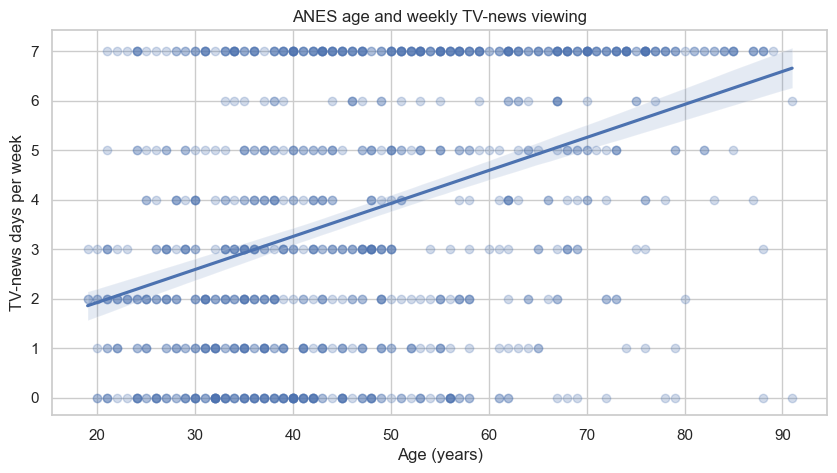

In [3]:
fig, ax = plt.subplots()
sns.regplot(x=x, y=y, scatter_kws={"alpha": .25}, ci=95, ax=ax)
ax.set(title="ANES age and weekly TV-news viewing", xlabel="Age (years)",
       ylabel="TV-news days per week")
plt.show()


## 10.2 Regression tests

In simple linear regression, the slope test $H_0:\beta_1=0$ is equivalent to the Pearson correlation
test. Regression extends the question to adjustment, nonlinear terms, and interactions. Valid standard
errors require an appropriate error structure; clustering and time dependence need specialized models.


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,0.5929,0.2415,2.4547,1.4279e-02,0.1189,1.0668
x1,0.0666,0.0048,13.7475,2.5070e-39,0.0571,0.0762


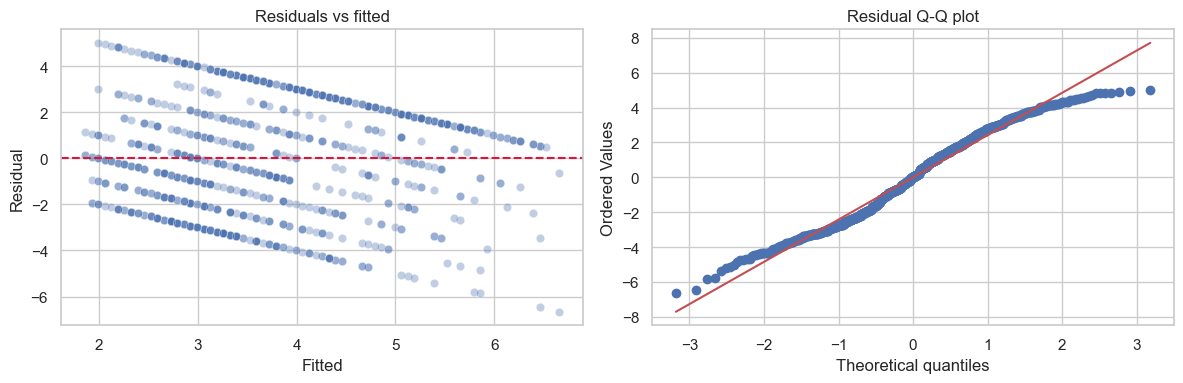

In [4]:
import statsmodels.api as sm
X = sm.add_constant(x)
regression = sm.OLS(y, X).fit()
display(regression.summary2().tables[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=regression.fittedvalues, y=regression.resid, alpha=.35, ax=axes[0])
axes[0].axhline(0, color="crimson", linestyle="--")
axes[0].set(title="Residuals vs fitted", xlabel="Fitted", ylabel="Residual")
stats.probplot(regression.resid, dist="norm", plot=axes[1])
axes[1].set_title("Residual Q-Q plot")
plt.tight_layout(); plt.show()


## Worked example and interpretation

### Association measures

The ANES example pairs each respondent's age with weekly TV-news viewing. Pearson's linear correlation is 0.409 with a Fisher-transformed 95% interval from 0.354 to 0.461. Spearman's rho is 0.399 and Kendall's tau is 0.291; all three tests have very small p-values. Their agreement suggests a positive relationship is not solely an artifact of one coefficient's scale. The scatterplot is needed to see ties, the bounded 0–7 viewing outcome, nonlinearity, and influential ages that a single coefficient can hide.

### Regression adds a scale

A simple linear regression estimates about 0.0666 more reported TV-news days per week for each additional year of age, with a 95% coefficient interval from 0.0571 to 0.0762. That slope is an average association in the fitted model, not a prediction that an individual changes by exactly that amount each year. The residual-versus-fitted and Q–Q plots diagnose patterns the model misses; a count or bounded-outcome model may be more appropriate for some analyses. These cross-sectional survey data cannot establish that aging itself causes the viewing difference, because cohorts and other factors may differ.

## Practice and solution

**Practice.** A correlation of .60 is observed between ice-cream sales and drownings. What is wrong
with concluding ice-cream causes drownings?

<details><summary>Solution</summary>

Association alone does not identify a causal effect. Temperature/season is a plausible common cause,
and aggregated time-series data may violate independence. A causal claim needs a defensible design and
adjustment strategy, not merely a small correlation p-value.
</details>

## Key takeaways

- Plot the relationship and inspect influential points.
- Match the coefficient to the data scale and relationship form.
- Regression adjusts associations under assumptions; it does not automatically remove confounding.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
